In [126]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


# Project Overview

This project explores how different optimization techniques can be used to train a Linear Regression model for salary prediction.

The dataset contains information about an employee's years of experience and salary. The goal is to understand how salary changes as experience increases and to build a model that can predict salary based on experience.

Instead of only using Scikit-Learn's built-in Linear Regression model, we will implement Gradient Descent from scratch to understand how machine learning models learn their parameters.

In this notebook we will:
1. Train a Linear Regression model using Scikit-Learn.
2. Implement Batch Gradient Descent from scratch by making our own BatchGDRegressor Class.
3. Implement Stochastic Gradient Descent (SGD) from scratch by making our own SGDRegressor Class.
4. Compare the results with Scikit-Learn's SGD implementation.
5. Analyze model performance, training time, and loss curves.

The objective is not only to make predictions but also to understand the mathematics and optimization process behind Linear Regression.

## Business Context

Suppose an HR department wants to estimate the salary of a new employee based on years of experience. Instead of manually deciding a salary, the company can use historical employee data to learn the relationship between experience and salary.

The model helps answer questions such as:
* How much does salary typically increase as experience increases?
* What salary should we expect for a candidate with a given level of experience?
* How strong is the relationship between experience and salary?

In [127]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

## A. Load data 

In [129]:
# Load the dataset 
df = pd.read_csv('/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv')

df = df.drop(columns=['Unnamed: 0'])
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [130]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [131]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


## B. Exploratory Data Analysis

In [132]:
# Feature and target
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

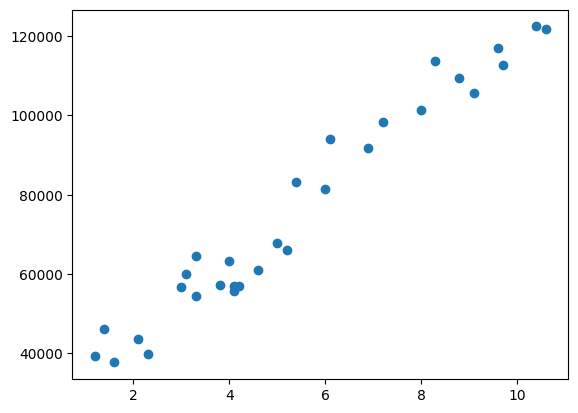

In [133]:
# Scatter plot to see our data
plt.scatter(X,y)

<Axes: xlabel='Salary', ylabel='Count'>

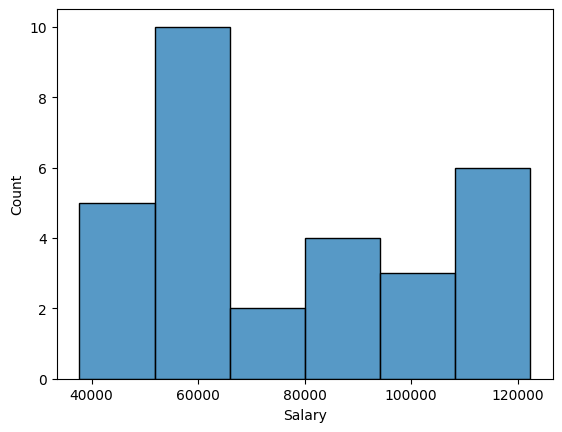

In [134]:
import seaborn as sns
sns.histplot(y)

<Axes: xlabel='YearsExperience', ylabel='Salary'>

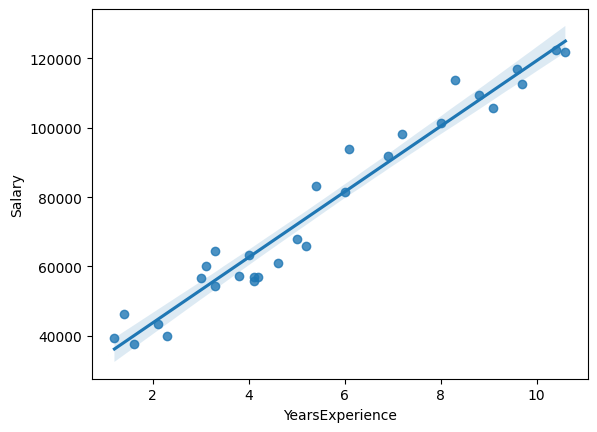

In [135]:
sns.regplot(x='YearsExperience', y='Salary',data=df)

In [136]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


## C. Train-Test-Split and Scaling

In [137]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=2)

Feature scaling was applied because Gradient Descent converges faster and more reliably when features are on a similar scale. Since the coefficient updates depend on feature magnitude, unscaled features can lead to very slow or unstable convergence.

In [138]:
# Scaling 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## D. Sklearn Baseline Linear Regression

In [139]:
reg = LinearRegression()

In [140]:
import time
start = time.time()
reg.fit(X_train, y_train)

reg_time = time.time() - start
print("The time taken is by Sklearn Linear Regression ",reg_time )

print("Value of Coefficient(m) by Sklearn Linear Regression ", reg.coef_)
print("Value of Intercept(b) by Sklearn Linear Regression", reg.intercept_)

y_pred = reg.predict(X_test)
from sklearn.metrics import r2_score
reg_r2_score = r2_score(y_test, y_pred)
print('Value of R2_score for Sklearn Linear Regression', reg_r2_score)

The time taken is by Sklearn Linear Regression  0.0016112327575683594
Value of Coefficient(m) by Sklearn Linear Regression  [26924.09005198]
Value of Intercept(b) by Sklearn Linear Regression 78502.20833333333
Value of R2_score for Sklearn Linear Regression 0.8886956733784561


## E. Batch Gradient Descent From Scratch (Our own Class)

Make a class to calculate the value of b and m

In [141]:
# Let's make our own class now and compare it with the sklearn class 
# This class is to practice how to calculate the value of b and m, for our understanding, 

class BatchGDRegressor:

    def __init__(self, learning_rate, epochs):
        self.m = 0
        self.b = 0
        self.lr = learning_rate
        self.epochs = epochs
        # Create an empty list and store the loss after every epoch
        self.losses = []
    
    def fit(self, X_train,y_train):
        X_train = np.array(X_train).ravel()
        y_train = np.array(y_train)
        n = len(X_train)
        
        # calculate b using gradient descent 
        for i in range(self.epochs):
            y_pred = self.m * X_train + self.b
            # Formula to find loss MSE=n1​∑(y−y^​)2
            loss = np.mean((y_train - y_pred)**2)
        
            #stores that value.
            self.losses.append(loss)
            # loss slope equation wrt b: L = -2 sumation (yi - mxi -b)
            # we can also do this: y_pred = self.m * X_train + self.b
            loss_slope_b = (-2/n) * np.sum(y_train - self.m*X_train.ravel() - self.b)
            
            # loss slope equation wrt m: L = -2 sumation(yi - mxi -b)*X
            loss_slope_m = (-2/n) * np.sum((y_train - self.m*X_train.ravel() - self.b)*X_train.ravel())
            
            # the equation for b(new) = b(old) - n * loss_slope_b # where n is the learning rate 
            self.b = self.b - (self.lr * loss_slope_b)
            
            # the equation for m(new) = m(old) - n * loss_slope_m # where n is the learning rate 
            self.m = self.m - (self.lr * loss_slope_m)

        # print("Value of Coefficient(m) for our own class of Batch GD=", self.m)
        # print("Value of Intercept(b) for our own class of Batch GD=", self.b)
        print("Initial Loss:",self.losses[0])
        print("Final Loss:",self.losses[-1])
    
    def predict(self, X_test):
        X_test = np.array(X_test).ravel()
        # from this equation : y = mx +b 
        return self.m * X_test + self.b

In [142]:
bgd_class = BatchGDRegressor(0.01, 1000)

The slope represents the relationship between experience and salary. In my model, the positive slope indicates that salary tends to increase as experience increases. The intercept represents the predicted salary when the feature value is zero. Since I standardized the experience variable before training, a feature value of zero corresponds to average experience. Therefore, the intercept can be interpreted as the predicted salary for an employee with average experience. The model estimates the baseline salary to be around $78,500, and salaries increase as experience increases.

* About m: The model learned that people with more experience generally earn more money.

* About b: The model estimates that a person with average experience earns about $78,500.

In [143]:
import time
start = time.time()
bgd_class.fit(X_train,y_train)

bgd_class_time = time.time() - start
y_pred = bgd_class.predict(X_test)

print("\n===== Our own class of  Batch GD =====")

print("Value of Coefficient(m) for our own class of Batch GD=", bgd_class.m)
print("Value of Intercept(b) for our own class of Batch GD=", bgd_class.b)

print("The time taken by our own class of Batch GD: ",bgd_class_time)

from sklearn.metrics import r2_score
bgd_r2_score = r2_score(y_test, y_pred)
print('Value of R2_score for our own class of Batch GD', bgd_r2_score)

Initial Loss: 6913425431.625
Final Loss: 25922093.287946895

===== Our own class of  Batch GD =====
Value of Coefficient(m) for our own class of Batch GD= 26924.090006664956
Value of Intercept(b) for our own class of Batch GD= 78502.20820121666
The time taken by our own class of Batch GD:  0.030721187591552734
Value of R2_score for our own class of Batch GD 0.888695671759141


We built a model that predicts salary based on years of experience. The model found a strong relationship between experience and salary. Based on our evaluation, around 89% of salary differences among employees can be explained by their years of experience alone. This indicates that experience is a very strong predictor of salary in this dataset.

In [144]:
bgd_class.predict(X_test)

array([36834.63204102, 34920.71466715, 67457.31002287, 59801.64052741,
       92338.23588312, 81811.69032686])

In [145]:
# b = 78502.20820121666
# m = 26924.090006664956
# lr = 0.01

# epochs = 1000

# for i in range(epochs):
#     n = len(X_train)
#     # we can also do this: y_pred = self.m * X_train + self.b
#     loss_slope_b = (-2/n) * np.sum(y_train - m*X_train.ravel() - b)
    
#     # loss slope equation wrt m: L = -2 sumation(yi - mxi -b)*X
#     loss_slope_m = (-2/n) * np.sum((y_train - m*X_train.ravel() - b)*X_train.ravel())
    
#     # the equation for b(new) = b(old) - n * loss_slope_b # where n is the learning rate 
#     b = b - (lr * loss_slope_b)
    
#     # the equation for m(new) = m(old) - n * loss_slope_m # where n is the learning rate 
#     m = m - (lr * loss_slope_m)

#     y_pred = m * X_test + b

#     plt.plot(X_test,y_pred)

# plt.scatter(X_train,y_train)

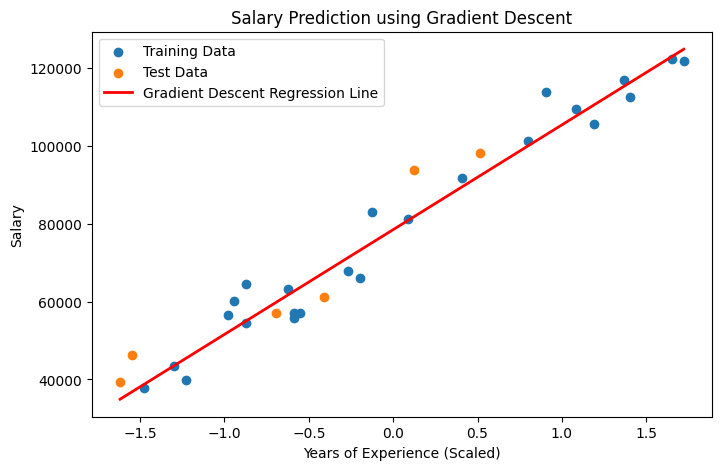

In [146]:
import numpy as np
import matplotlib.pyplot as plt

b = 78502.20820121666
m = 26924.090006664956
lr = 0.01

# Combine train and test data
X_all = np.concatenate([X_train.ravel(), X_test.ravel()])

# Calculate predictions using learned m and b
y_pred_all = m * X_all + b

# Sort values so matplotlib draws a straight line
sorted_idx = np.argsort(X_all)

# Plot actual observations
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, label="Training Data")
plt.scatter(X_test, y_test, label="Test Data")

# Plot regression line
plt.plot(
    X_all[sorted_idx],
    y_pred_all[sorted_idx],
    color="red",
    linewidth=2,
    label="Gradient Descent Regression Line"
)

plt.xlabel("Years of Experience (Scaled)")
plt.ylabel("Salary")
plt.title("Salary Prediction using Gradient Descent")
plt.legend()

plt.show()

Each blue dot represents a real employee. The position of the dot shows their experience and salary. The red line is the model's prediction. Since the line trends upward, it indicates that employees with more experience tend to earn higher salaries. The closer the dots are to the line, the better the model fits the data.

## F. Stochastic Gradient Descent From Scratch (Our own Class)

In [147]:
class SGDRegressorScratch:

    def __init__(self, learning_rate=0.01, epochs=100):

        self.coef_ = None
        self.intercept_ = None

        self.lr = learning_rate
        self.epochs = epochs
        
        self.losses = []

    def fit(self, X_train, y_train):
        # init your coefs and intercept
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for epoch in range(self.epochs):
            for row in range(X_train.shape[0]):
                idx = np.random.randint(0,X_train.shape[0])

                y_hat = (np.dot(X_train[idx],self.coef_) + self.intercept_)

                intercept_der = (-2 * (y_train.iloc[idx] - y_hat))
                self.intercept_ = (self.intercept_ - self.lr * intercept_der)

                coef_der = (-2 * (y_train.iloc[idx] - y_hat) * X_train[idx])
                self.coef_ = (self.coef_ - self.lr * coef_der)
                epoch_pred = (np.dot(X_train, self.coef_) + self.intercept_)
                loss = np.mean((y_train - epoch_pred)**2)
                self.losses.append(loss)

        # print("Intercept =", self.intercept_)
        # print("Coefficient =", self.coef_[0])
        print("Initial Loss:", self.losses[0])
        print("Final Loss:",self.losses[-1])

    def predict(self, X_test):
        return (np.dot(X_test, self.coef_) + self.intercept_)

In [148]:
np.random.seed(42)

sgd_class = SGDRegressorScratch(learning_rate=0.01, epochs=100)

import time
start = time.time()
sgd_class.fit(X_train, y_train)

sgd_class_time = time.time() - start

y_pred_sgd = sgd_class.predict(X_test)

sgd_class_r2_score = r2_score(y_test, y_pred_sgd)

print("\n===== Our own class of SGD =====")
print("Coefficient(m) for our own class of SGD:",sgd_class.coef_[0])
print("Intercept(b) for our own class of SGD:",sgd_class.intercept_)
print("R2_score for our own class of SGD:", sgd_class_r2_score)
print("Time for our own class of SGD:", sgd_class_time)

Initial Loss: 6772327016.479674
Final Loss: 26162087.435557842

===== Our own class of SGD =====
Coefficient(m) for our own class of SGD: 26658.245474352898
Intercept(b) for our own class of SGD: 78090.72223617004
R2_score for our own class of SGD: 0.884487593027566
Time for our own class of SGD: 0.6331217288970947


## G. Stochastic Gradient Descent with Sklearn SGDRegressor Class

In [149]:
from sklearn.linear_model import SGDRegressor

sgd_sk = SGDRegressor(max_iter=1000, eta0=0.01, learning_rate='constant', random_state=42)

start = time.time()
sgd_sk.fit(X_train, y_train)

sgd_sk_time = time.time() - start

y_pred_sk = sgd_sk.predict(X_test)

sgd_sk_r2 = r2_score(y_test, y_pred_sk)

print("\n===== SKLEARN SGD =====")
print("Coefficient(m) for Sklearn SGDRegressor:", sgd_sk.coef_[0])
print("Intercept(b) for Sklearn SGDRegressor:", sgd_sk.intercept_[0])
print("R²_score for Sklearn SGDRegressor:", sgd_sk_r2)
print("Time for Sklearn SGDRegressor:", sgd_sk_time)


===== SKLEARN SGD =====
Coefficient(m) for Sklearn SGDRegressor: 26966.17747111615
Intercept(b) for Sklearn SGDRegressor: 78500.81402500179
R²_score for Sklearn SGDRegressor: 0.8883175520759252
Time for Sklearn SGDRegressor: 0.0019071102142333984


## Mini-Batch Gradient Descent From Scratch (Our own Class)

In [150]:
import random
class MBGDRegressor:
    
    def __init__(self,batch_size = 50,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        
        self.losses = []
        
    def fit(self,X_train,y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            for j in range(int(X_train.shape[0]/self.batch_size)):
                idx = random.sample(range(X_train.shape[0]),self.batch_size)
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
                #print("Shape of y_hat",y_hat.shape)
                intercept_der = -2 * np.mean(y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = (-2 * np.dot((y_train[idx] - y_hat),X_train[idx])) / self.batch_size

                # coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)
                
            epoch_pred = (np.dot(X_train, self.coef_) + self.intercept_)
            loss = np.mean((y_train - epoch_pred)**2)
            self.losses.append(loss)
        print(self.intercept_,self.coef_)
        print("Initial Loss:", self.losses[0])
        print("Final Loss:",self.losses[-1])
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [151]:
mbgdr_scratch = MBGDRegressor(batch_size=8, learning_rate=0.01, epochs=100)

In [152]:
print(y_train.index)

Index([23,  6,  3, 20,  5, 27, 12,  4, 10, 16, 28, 25, 17,  2,  7, 26, 24, 18,
       11, 22, 29, 13, 15,  8],
      dtype='int64')


In [153]:
start = time.time()
mbgdr_scratch.fit(X_train, y_train)

mbgdr_scratch_time = time.time() - start

y_pred = mbgdr_scratch.predict(X_test)
mbgdr_scratch_r2_score = r2_score(y_test,y_pred)

print("\n===== Mini-Batch Gradient Descent From Scratch  =====")
print("Coefficient(m) for Mini-Batch Gradient Descent From Scratch:", mbgdr_scratch.coef_)
print("Intercept(b) for Mini-Batch Gradient Descent From Scratch:", mbgdr_scratch.intercept_)
print("R²_score for Mini-Batch Gradient Descent From Scratch:", mbgdr_scratch_r2_score)
print("Time for Mini-Batch Gradient Descent From Scratch:", mbgdr_scratch_time)

78165.8773300576 [26957.07046277]
Initial Loss: 6023512266.096169
Final Loss: 26036299.53920756

===== Mini-Batch Gradient Descent From Scratch  =====
Coefficient(m) for Mini-Batch Gradient Descent From Scratch: [26957.07046277]
Intercept(b) for Mini-Batch Gradient Descent From Scratch: 78165.8773300576
R²_score for Mini-Batch Gradient Descent From Scratch: 0.883074811402998
Time for Mini-Batch Gradient Descent From Scratch: 0.02393198013305664


## SKlearn Mini-Batch Gradient Descent Class

In [158]:
from sklearn.linear_model import SGDRegressor
import random

mbgdr_class = SGDRegressor(learning_rate='constant',eta0=0.01,random_state=42)
start = time.time()

batch_size = 8

for epoch in range(100):
    idx = random.sample(range(X_train.shape[0]),batch_size)
    mbgdr_class.partial_fit(X_train[idx], y_train.iloc[idx])

mbgdr_class_time = time.time() - start

In [159]:
y_pred = mbgdr_class.predict(X_test)
mbgdr_class_r2_score = r2_score(y_test,y_pred)

print("\n===== SKLEARN Mini-Batch Gradient Descent  =====")
print("Coefficient(m) for Mini-Batch Gradient Descent From Scratch:", mbgdr_class.coef_)
print("Intercept(b) for Mini-Batch Gradient Descent From Scratch:", mbgdr_class.intercept_)
print("R²_score for Mini-Batch Gradient Descent From Scratch:", mbgdr_class_r2_score)
print("Time for Mini-Batch Gradient Descent From Scratch:", mbgdr_class_time)


===== SKLEARN Mini-Batch Gradient Descent  =====
Coefficient(m) for Mini-Batch Gradient Descent From Scratch: [27120.03712501]
Intercept(b) for Mini-Batch Gradient Descent From Scratch: [78087.98988633]
R²_score for Mini-Batch Gradient Descent From Scratch: 0.880169994546413
Time for Mini-Batch Gradient Descent From Scratch: 0.1167306900024414


## H. Comparison Table

In [161]:
results = pd.DataFrame({

    "Model": ["LinearRegression", "Batch GD", "Scratch SGD", "Sklearn SGD", "Mini-BatchGD Scratch","Sklearn Mini-BatchGD"],
              
    "Coefficient": [reg.coef_[0], bgd_class.m, sgd_class.coef_[0], sgd_sk.coef_[0], mbgdr_scratch.coef_, mbgdr_class.coef_],

    "Intercept": [reg.intercept_, bgd_class.b, sgd_class.intercept_, sgd_sk.intercept_[0],mbgdr_scratch.intercept_, mbgdr_class.intercept_],

    "R2": [reg_r2_score, bgd_r2_score, sgd_class_r2_score, sgd_sk_r2,mbgdr_scratch_r2_score, mbgdr_class_r2_score],

    "Time": [reg_time, bgd_class_time, sgd_class_time, sgd_sk_time, mbgdr_scratch_time, mbgdr_class_time]})

results

,Model,Coefficient,Intercept,R2,Time
0,LinearRegression,26924.090052,78502.208333,0.888696,0.001611
1,Batch GD,26924.090007,78502.208201,0.888696,0.030721
2,Scratch SGD,26658.245474,78090.722236,0.884488,0.633122
3,Sklearn SGD,26966.177471,78500.814025,0.888318,0.001907
4,Mini-BatchGD Scratch,[26957.070462772866],78165.87733,0.883075,0.023932
5,Sklearn Mini-BatchGD,[27120.03712501461],[78087.98988633469],0.880170,0.116731


## I. Technical Conclusion

The goal of this project was to understand how different optimization algorithms learn the parameters of a Linear Regression model while predicting salaries based on years of experience.

To achieve this, Linear Regression was trained using several approaches:

1. Scikit-Learn Linear Regression (analytical solution)
2. Batch Gradient Descent (implemented from scratch)
3. Stochastic Gradient Descent (implemented from scratch)
4. Mini-Batch Gradient Descent (implemented from scratch)Scikit-Learn SGD-based implementations

The results showed that all methods learned a very similar relationship between years of experience and salary. Batch Gradient Descent produced results almost identical to Scikit-Learn's Linear Regression model, confirming the correctness of the implementation.

The loss curves highlighted the differences in learning behavior: Batch GD converged smoothly, SGD showed more fluctuations due to random updates, and Mini-Batch GD provided a balance between the two.

Overall, all methods achieved comparable performance, demonstrating that different optimization techniques can reach similar solutions while following different learning paths. This project provided valuable hands-on experience with Gradient Descent and the fundamentals of model optimization.

## J. Loss Curve Comparison

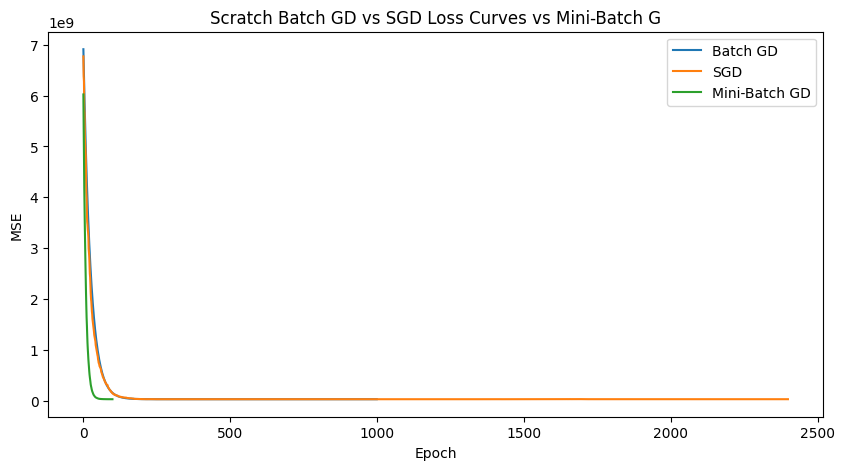

In [162]:
plt.figure(figsize=(10,5))

plt.plot(bgd_class.losses,label="Batch GD")

plt.plot(sgd_class.losses, label="SGD")

plt.plot(mbgdr_scratch.losses, label="Mini-Batch GD")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Scratch Batch GD vs SGD Loss Curves vs Mini-Batch G")
plt.legend()
plt.show()

### Interpretation of the Loss Curve

* All three algorithms (Batch GD, SGD, and Mini-Batch GD) start with a very high error because the model initially has poor values for the coefficient and intercept.
* During the first few epochs, the error decreases very quickly, showing that the model is learning the relationship between years of experience and salary.
* Mini-Batch Gradient Descent reduces the error slightly faster than the other methods.
* Stochastic Gradient Descent takes a little longer to settle because it updates the model using one observation at a time, which introduces some randomness into the learning process.
* After approximately 250 epochs, all three methods reach nearly the same minimum error, and the curves flatten.
* This means the models have finished learning and further training does not significantly improve performance.


## K.  Business Questions
1. Does experience have an impact on salary?
Yes, the positive coefficient shows that salary increases as experience increases.
Employees with more experience tend to earn higher salaries. Years of experience are a strong predictor of salary in this dataset.

3. How strong is the relationship between experience and salary?
Strong. R² ≈ 0.89. This means approximately 89% of salary variation can be explained by years of experience.

4. Can we estimate the salary for future employees?
Yes. The model can be used to predict salary based on years of experience.

### Key Findings

1. Years of experience is strongly associated with salary.
2. Batch Gradient Descent successfully recovered the same solution as Linear Regression.
3. SGD reached a low loss in fewer epochs.
4. All methods produced similar predictive performance.